# `qufin.wyckoff` Tutorial

An end-to-end walkthrough of the **wyckoff** subpackage: a quantitative toolkit for Wyckoff-method market analysis.

**What Wyckoff theory is, in one paragraph.** The Wyckoff method, formalised by Richard D. Wyckoff in the 1930s, reads markets through the footprints of a *composite operator* — institutional players who accumulate stock during ranges and distribute it at tops. Price moves in four macro-phases (Accumulation → Markup → Distribution → Markdown), and within each accumulation/distribution range it is traditional to mark out *Phases A–E* and a sequence of canonical events (PS, SC, AR, ST, Spring, SOS, LPS …). Three laws govern everything: Supply & Demand, Cause & Effect, and Effort vs Result.

**What this notebook covers.**

1. Bar primitives — `OHLCV`, validation, true range, ATR, rolling z-scores.
2. Swing-point detection — fractal pivots and percent-reversal ZigZag.
3. Trading-range detection — finding lateral consolidations.
4. Volume profile — POC, value area, anchored VWAP.
5. Effort vs Result — quantifying absorption.
6. Schematic event detection — SC, AR, ST, Spring, SOS, LPS.
7. Rule-based phase classification (Phases A–E).
8. HMM-based macro-phase classification (Accumulation / Markup / Distribution / Markdown).
9. Point-and-figure with cause-and-effect price targets.
10. Wyckoff-style relative strength.

All data here is synthetic so the notebook runs offline. Swap in `yfinance.download(...)` and `OHLCV.from_records(...)` to point any of these analytics at real bars.

In [1]:
from __future__ import annotations

from datetime import UTC, datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from qufin.wyckoff import (
    BAR_SCHEMA,
    OHLCV,
    TradingRange,
    WyckoffHMMClassifier,
    anchored_vwap,
    atr,
    classify_phases,
    detect_automatic_rally,
    detect_climax,
    detect_secondary_test,
    detect_sos_lps,
    detect_spring,
    detect_trading_ranges,
    effort_vs_result,
    find_swings,
    horizontal_count,
    pnf_from_bars,
    relative_strength,
    rs_rank,
    true_range,
    vertical_count,
    volume_profile,
    zigzag,
)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

rng = np.random.default_rng(7)

## 0. Build a synthetic accumulation schematic

We construct an idealised four-act story so every detector has something visible to find:

1. **Markdown** — 80 bars of negative drift (the prior down-leg into the range).
2. **Selling Climax** — a single wide-range, high-volume bar that closes in the upper third.
3. **Trading range** — 90 bars oscillating between support and resistance, with one **Spring** (a false break below support that recovers within a few bars).
4. **Sign of Strength** — a wide-range, high-volume bar breaking above the range, followed by an **LPS** pullback, then markup.

Volumes are scaled to mark the climax and the SOS — a quirk of synthetic data, not the algorithms.

In [2]:
def make_accumulation_schematic(seed: int = 11) -> OHLCV:
    r = np.random.default_rng(seed)

    # 1) Markdown leg — log-drift downwards.
    n_md = 80
    log_steps = r.normal(-0.012, 0.005, n_md)
    md_close = 150.0 * np.exp(np.cumsum(log_steps))

    # 2) Range floor we want the SC to sit just below.
    support = float(md_close[-1] * 0.96)
    resistance = support * 1.10

    # 3) Range body — 90 bars mean-reverting between support and resistance.
    n_rg = 90
    rg_close = np.empty(n_rg)
    rg_close[0] = 0.5 * (support + resistance)
    for i in range(1, n_rg):
        target = 0.5 * (support + resistance)
        rg_close[i] = rg_close[i - 1] + 0.15 * (target - rg_close[i - 1]) + r.normal(0, 0.6)
        rg_close[i] = float(np.clip(rg_close[i], support + 0.2, resistance - 0.2))

    # Plant a spring at bar 60 of the range.
    k_spring = 60
    rg_close[k_spring] = support - 0.6     # poke below support
    rg_close[k_spring + 1] = support + 0.4
    rg_close[k_spring + 2] = support + 1.5

    # 4) Breakout (markup).
    n_up = 40
    up_close = resistance + 1.5 + np.cumsum(np.abs(r.normal(0.6, 0.2, n_up)))

    close = np.concatenate([md_close, rg_close, up_close])
    n = close.shape[0]
    open_ = np.concatenate(([close[0]], close[:-1]))

    # Manufacture per-bar high/low.
    body = np.abs(close - open_)
    wick = r.uniform(0.1, 0.5, n) * (1.0 + body)
    high = np.maximum(open_, close) + wick
    low = np.minimum(open_, close) - wick

    # Volume baseline + climax + SOS spikes.
    vol = r.lognormal(mean=10.0, sigma=0.15, size=n)
    k_sc = n_md - 1
    k_sos = n_md + n_rg                                  # first bar after the range
    # SC bar — paint a wide range with close in the upper third.
    sc_low = md_close[-1] - 5.0
    sc_high = md_close[-1] + 2.0
    low[k_sc] = sc_low
    high[k_sc] = sc_high
    close[k_sc] = sc_high - (sc_high - sc_low) * 0.25     # upper third
    open_[k_sc] = md_close[-2]
    vol[k_sc] = vol.mean() * 30.0

    # SOS bar — wide-range, close > resistance, big volume.
    sos_low = resistance - 0.5
    sos_high = resistance + 6.0
    low[k_sos] = sos_low
    high[k_sos] = sos_high
    open_[k_sos] = resistance - 0.2
    close[k_sos] = sos_high - 0.5
    vol[k_sos] = vol.mean() * 25.0

    # LPS pullback (just after SOS) — low volume, low holds above resistance.
    for j in range(k_sos + 1, k_sos + 4):
        close[j] = resistance + 0.8
        open_[j] = close[j - 1]
        high[j] = close[j] + 0.4
        low[j] = resistance + 0.1
        vol[j] = vol.mean() * 0.6

    # Build the polars frame.
    ts = [datetime(2024, 1, 1, tzinfo=UTC) + timedelta(days=i) for i in range(n)]
    df = pl.DataFrame(
        {
            'timestamp': ts,
            'open': open_,
            'high': high,
            'low': low,
            'close': close,
            'volume': vol,
        },
        schema={name: dtype for name, dtype in BAR_SCHEMA.items()},
    )
    return OHLCV(data=df, symbol='WYCK')


bars = make_accumulation_schematic()
print(f'{len(bars)} bars, symbol={bars.symbol}')
print(bars.data.head(3))

210 bars, symbol=WYCK
shape: (3, 6)
┌─────────────────────────┬────────────┬────────────┬────────────┬────────────┬──────────────┐
│ timestamp               ┆ open       ┆ high       ┆ low        ┆ close      ┆ volume       │
│ ---                     ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---          │
│ datetime[ns, UTC]       ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64          │
╞═════════════════════════╪════════════╪════════════╪════════════╪════════════╪══════════════╡
│ 2024-01-01 00:00:00 UTC ┆ 148.236098 ┆ 148.340685 ┆ 148.13151  ┆ 148.236098 ┆ 26647.734476 │
│ 2024-01-02 00:00:00 UTC ┆ 148.236098 ┆ 148.460809 ┆ 147.242374 ┆ 147.467085 ┆ 24128.526804 │
│ 2024-01-03 00:00:00 UTC ┆ 147.467085 ┆ 147.996318 ┆ 146.073818 ┆ 146.603051 ┆ 21666.989299 │
└─────────────────────────┴────────────┴────────────┴────────────┴────────────┴──────────────┘


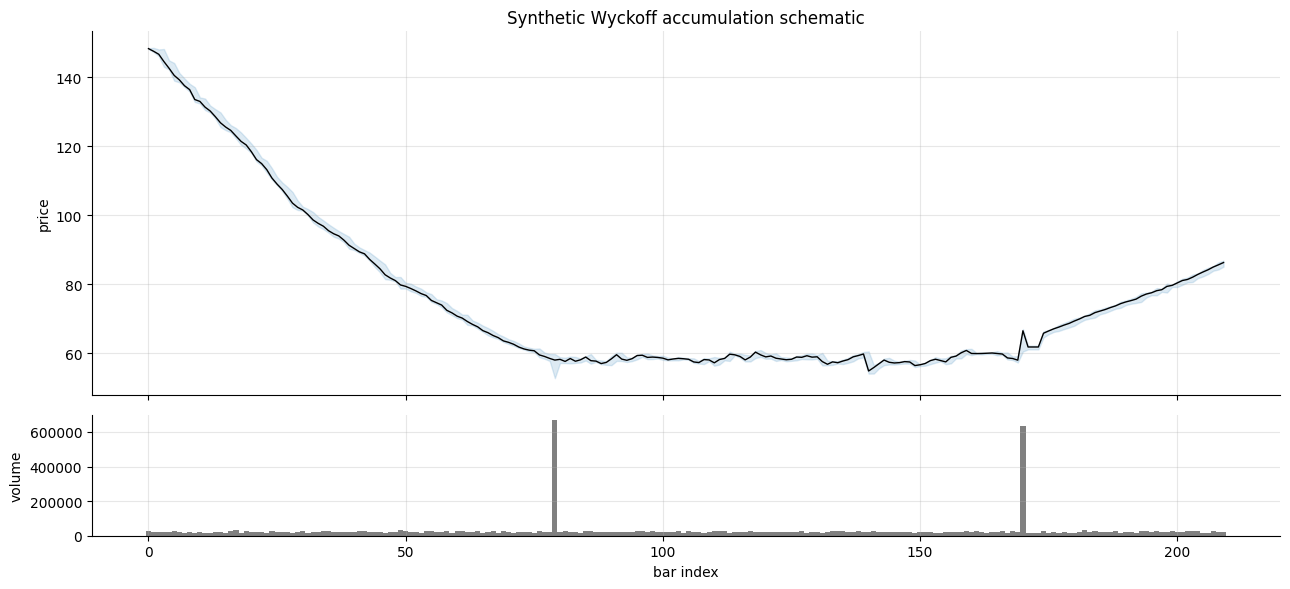

In [3]:
fig, (ax_p, ax_v) = plt.subplots(2, 1, sharex=True, height_ratios=[3, 1], figsize=(13, 6))
ax_p.plot(bars.close(), color='black', lw=1.0)
ax_p.fill_between(range(len(bars)), bars.low(), bars.high(), color='C0', alpha=0.15)
ax_p.set_title('Synthetic Wyckoff accumulation schematic')
ax_p.set_ylabel('price')
ax_v.bar(range(len(bars)), bars.volume(), color='gray', width=1.0)
ax_v.set_ylabel('volume')
ax_v.set_xlabel('bar index')
plt.tight_layout()
plt.show()

## 1. Bar primitives — true range, ATR, rolling z-scores

`OHLCV` is a thin polars wrapper enforcing the canonical schema. The bar-level helpers are numba-jitted and return float64 numpy arrays.

* `true_range(bars)` — Wilder's TR per bar.
* `atr(bars, window=14)` — Wilder-smoothed ATR; the first `window-1` entries are NaN by design.
* `normalize_volume(bars, window=50)` — rolling z-score of volume — the input to every climax/SOS detector.

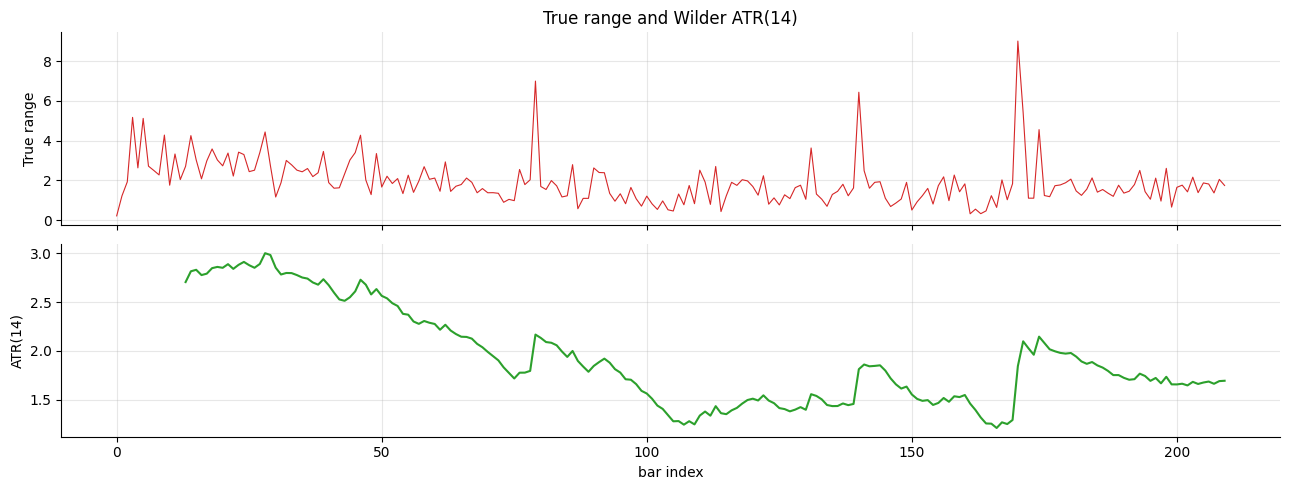

In [4]:
tr = true_range(bars)
a = atr(bars, window=14)

fig, (ax_tr, ax_atr) = plt.subplots(2, 1, sharex=True, figsize=(13, 5))
ax_tr.plot(tr, color='C3', lw=0.8)
ax_tr.set_ylabel('True range')
ax_atr.plot(a, color='C2')
ax_atr.set_ylabel('ATR(14)')
ax_atr.set_xlabel('bar index')
ax_tr.set_title('True range and Wilder ATR(14)')
plt.tight_layout()
plt.show()

## 2. Swing-point detection

Two algorithms for marking pivots:

* **Fractal swings** (`find_swings`) — Bill-Williams style. A bar is a swing high iff its `high` strictly exceeds the highs of the `left` bars before and the `right` bars after.
* **ZigZag** (`zigzag`) — emits a pivot only after a counter-move of at least `pct`. Good for noisy intraday series.

Both return a list of `SwingPoint` dataclasses (`idx`, `timestamp`, `price`, `kind`, `strength`).

13 fractal swings, 35 zigzag pivots


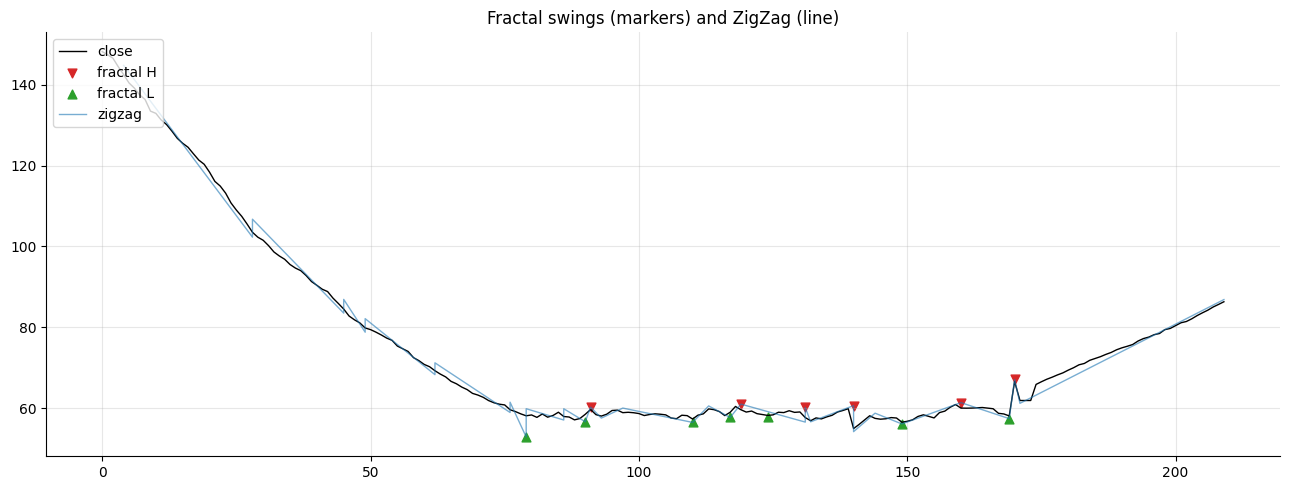

In [5]:
fractals = find_swings(bars, left=5, right=5)
zz = zigzag(bars, pct=0.04)
print(f'{len(fractals)} fractal swings, {len(zz)} zigzag pivots')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(bars.close(), color='black', lw=1.0, label='close')
fr_h = [s for s in fractals if s.kind == 'H']
fr_l = [s for s in fractals if s.kind == 'L']
ax.scatter([s.idx for s in fr_h], [s.price for s in fr_h], marker='v', color='C3', s=40, label='fractal H')
ax.scatter([s.idx for s in fr_l], [s.price for s in fr_l], marker='^', color='C2', s=40, label='fractal L')
ax.plot([s.idx for s in zz], [s.price for s in zz], color='C0', lw=1.0, alpha=0.6, label='zigzag')
ax.set_title('Fractal swings (markers) and ZigZag (line)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 3. Trading-range detection

`detect_trading_ranges` slides a window over the bars and flags segments whose price extreme is narrow relative to local ATR. Overlapping qualifying windows are merged into the longest contiguous run.

TradingRange  bars [ 70, 170)  support=52.82  resistance=64.11  width=11.28


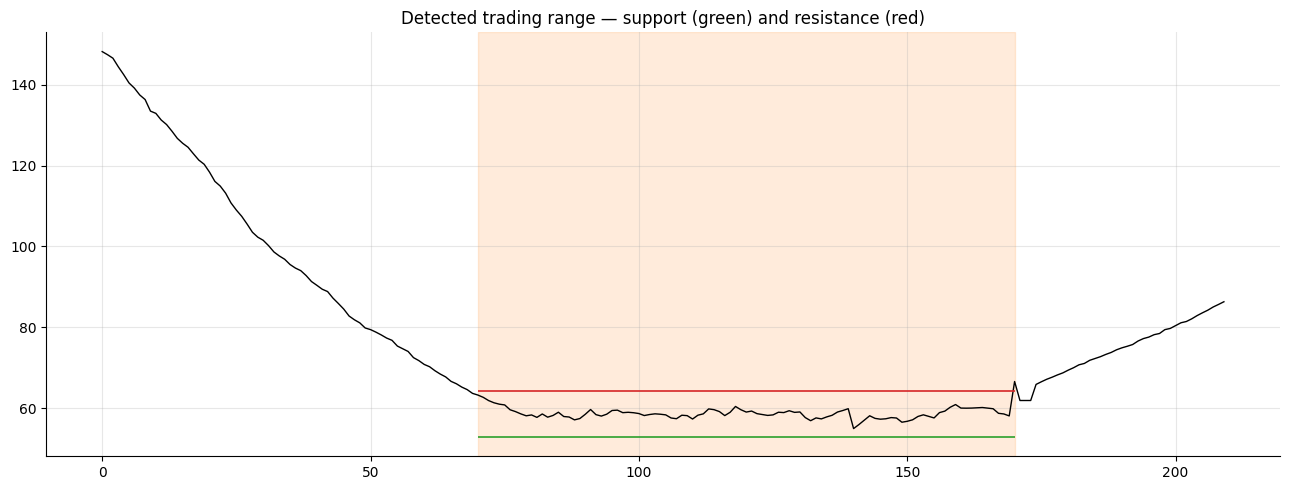

In [6]:
ranges = detect_trading_ranges(bars, min_bars=25, max_width_atr=6.0)
for r in ranges:
    print(
        f'TradingRange  bars [{r.start_idx:3d}, {r.end_idx:3d})  '
        f'support={r.support:.2f}  resistance={r.resistance:.2f}  '
        f'width={r.width:.2f}'
    )

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(bars.close(), color='black', lw=1.0)
for r in ranges:
    ax.axvspan(r.start_idx, r.end_idx, alpha=0.15, color='C1')
    ax.hlines(r.support, r.start_idx, r.end_idx, color='C2', lw=1.2)
    ax.hlines(r.resistance, r.start_idx, r.end_idx, color='C3', lw=1.2)
ax.set_title('Detected trading range — support (green) and resistance (red)')
plt.tight_layout()
plt.show()

## 4. Volume profile and anchored VWAP

`volume_profile` distributes each bar's volume uniformly across its high-low range, then

* picks the **POC** (Point of Control) — the bin centre with the most volume;
* widens out from the POC until 70% of total volume is captured — that band is the **value area** (VAL / VAH);
* identifies **HVN** / **LVN** as local maxima / minima of the histogram.

`anchored_vwap` computes a running VWAP from any chosen anchor bar — typically a climax, a spring, or the start of a new session.

POC=58.61   VAL=57.05   VAH=60.16


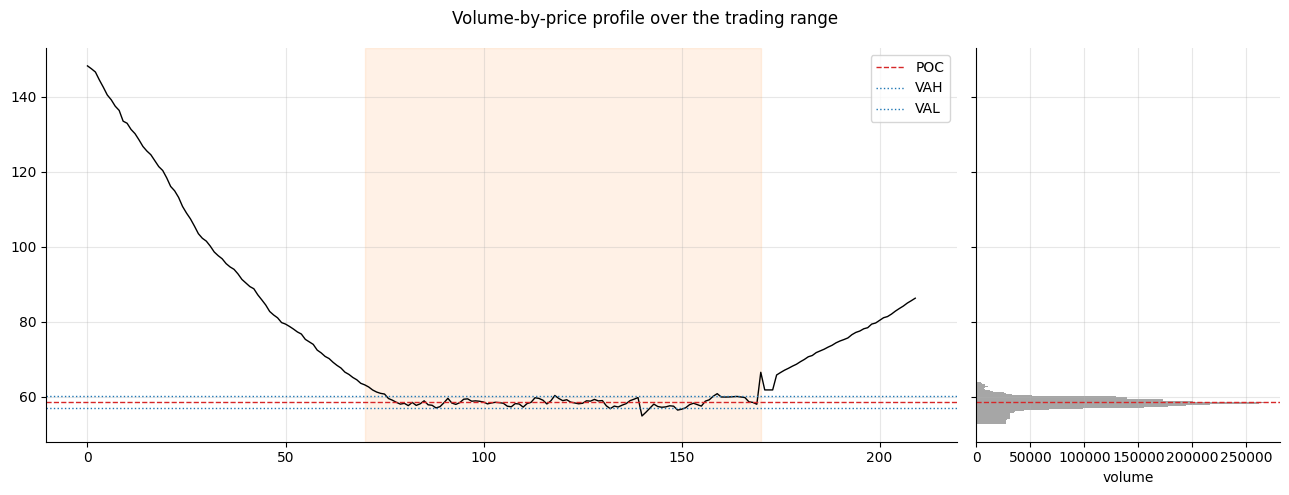

In [7]:
rng_first = ranges[0]
profile = volume_profile(bars, n_bins=40, start=rng_first.start_idx, end=rng_first.end_idx)
print(f'POC={profile.poc:.2f}   VAL={profile.val:.2f}   VAH={profile.vah:.2f}')

fig, (ax_px, ax_vp) = plt.subplots(1, 2, sharey=True, figsize=(13, 5), width_ratios=[3, 1])
ax_px.plot(bars.close(), color='black', lw=1.0)
ax_px.axvspan(rng_first.start_idx, rng_first.end_idx, alpha=0.10, color='C1')
ax_px.axhline(profile.poc, color='C3', ls='--', lw=1.0, label='POC')
ax_px.axhline(profile.vah, color='C0', ls=':', lw=1.0, label='VAH')
ax_px.axhline(profile.val, color='C0', ls=':', lw=1.0, label='VAL')
ax_px.legend()
centres = 0.5 * (profile.price_bins[:-1] + profile.price_bins[1:])
ax_vp.barh(centres, profile.volume, height=np.diff(profile.price_bins), color='gray', alpha=0.7)
ax_vp.axhline(profile.poc, color='C3', ls='--', lw=1.0)
ax_vp.set_xlabel('volume')
plt.suptitle('Volume-by-price profile over the trading range')
plt.tight_layout()
plt.show()

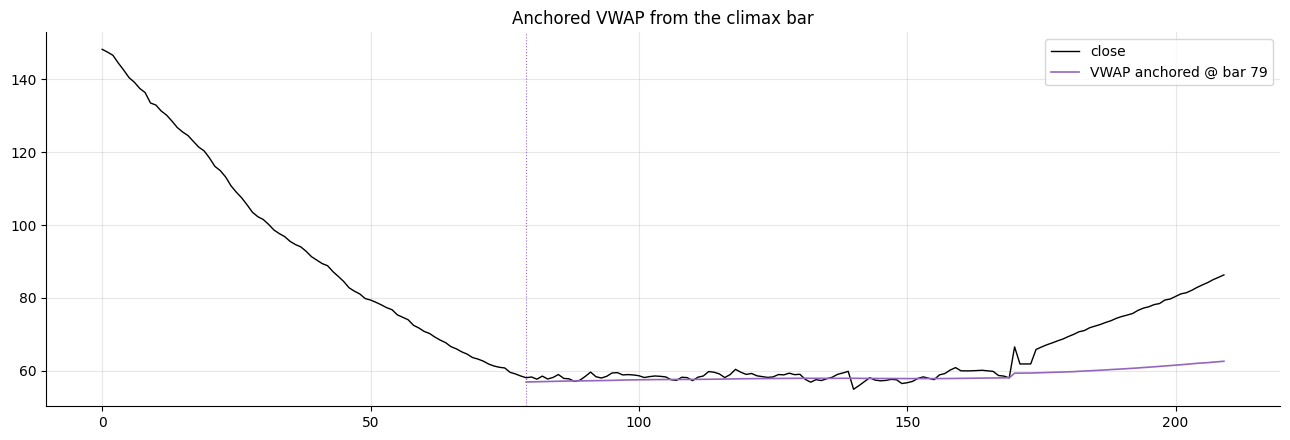

In [8]:
# Anchor the VWAP at the selling climax — "from the moment the operator started buying".
# We'll re-discover the SC's index in the next section; here we just pick the bar with
# the highest volume in the markdown leg as a reasonable proxy.
k_anchor = int(np.argmax(bars.volume()[:rng_first.start_idx + 10]))
vwap = anchored_vwap(bars, anchor_idx=k_anchor)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(bars.close(), color='black', lw=1.0, label='close')
ax.plot(vwap, color='C4', lw=1.2, label=f'VWAP anchored @ bar {k_anchor}')
ax.axvline(k_anchor, color='C4', ls=':', lw=0.8)
ax.set_title('Anchored VWAP from the climax bar')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Effort vs Result

Wyckoff's third law: a *bullish absorption bar* shows heavy **effort** (volume) with little downward **result** (body relative to true range). It signals supply being absorbed by larger demand.

We compute rolling z-scores of `log(volume)` and `|close-open|/TR` and flag bars where effort is high but result is low.

5 absorption bars flagged: [42, 49, 79, 161, 168]


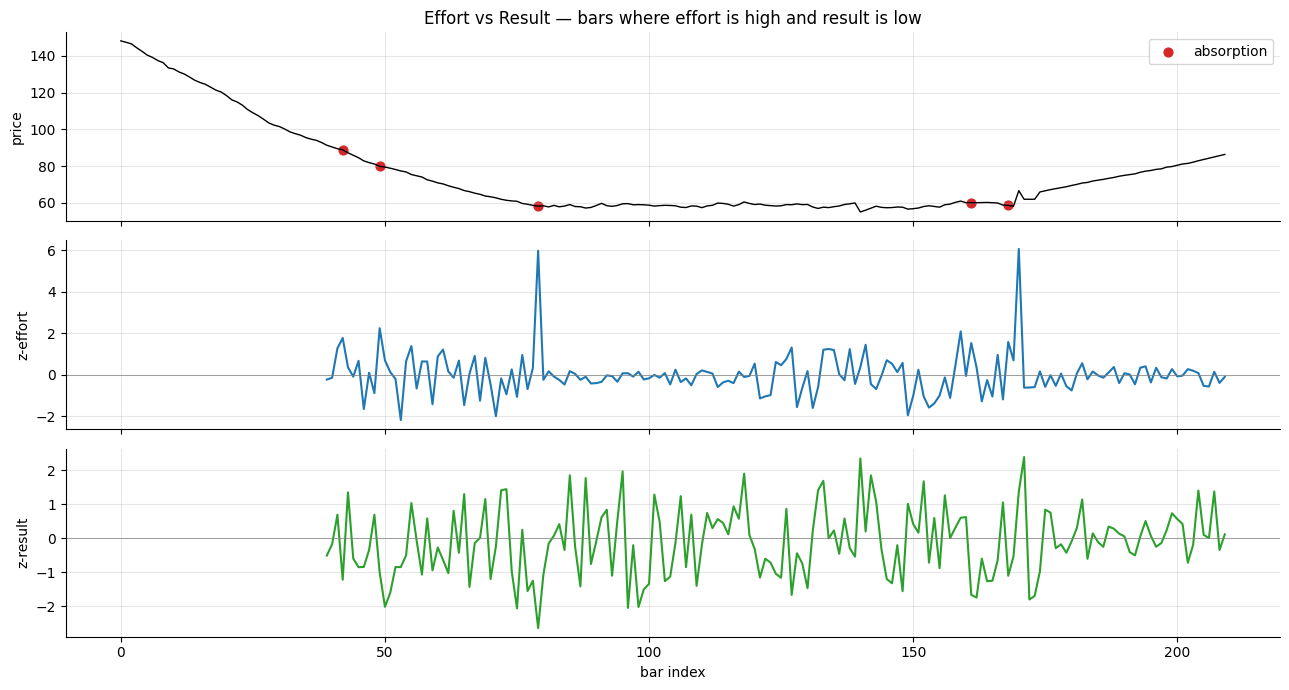

In [9]:
er = effort_vs_result(bars, window=40, effort_z=1.5, result_z=-0.3)
flagged = np.where(er.flag_absorption)[0]
print(f'{len(flagged)} absorption bars flagged: {flagged.tolist()}')

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(13, 7))
axes[0].plot(bars.close(), color='black', lw=1.0)
axes[0].scatter(flagged, bars.close()[flagged], color='C3', marker='o', s=40, label='absorption')
axes[0].set_ylabel('price')
axes[0].legend()
axes[1].plot(er.z_effort, color='C0')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_ylabel('z-effort')
axes[2].plot(er.z_result, color='C2')
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].set_ylabel('z-result')
axes[2].set_xlabel('bar index')
axes[0].set_title('Effort vs Result — bars where effort is high and result is low')
plt.tight_layout()
plt.show()

## 6. Schematic event detection — SC → AR → ST → Spring → SOS → LPS

Every detector is deterministic and threshold-based. Defaults follow standard Wyckoff heuristics; every threshold is a keyword argument so you can tune for timeframe and asset.

In [10]:
climaxes = detect_climax(bars, vol_window=40, trend_window=20, z_volume=2.0, z_range=1.5)
for c in climaxes:
    print(f'{c.kind} @ bar {c.idx}  z_vol={c.z_volume:.2f}  z_rng={c.z_range:.2f}  price={c.price:.2f}')

sc = next(c for c in climaxes if c.kind == 'SC')
ar = detect_automatic_rally(bars, sc, max_bars=20)
st = detect_secondary_test(bars, sc, ar, tolerance_atr=2.0, max_bars=60) if ar else None
print(f'AR: {ar}')
print(f'ST: {st}')

SC @ bar 79  z_vol=6.24  z_rng=4.68  price=52.82
AR: StructuralEvent(idx=91, kind='AR', price=60.23122195124831, z_volume=-0.17310713953022586)
ST: StructuralEvent(idx=107, kind='ST', price=57.0593122242305, z_volume=-0.1501197182840534)


In [11]:
springs = detect_spring(bars, rng_first, max_penetration_atr=3.0, recovery_bars=5)
sos, lps = detect_sos_lps(bars, rng_first, breakout_z_volume=1.0, breakout_z_range=1.0, lookahead=20)
print(f'{len(springs)} spring(s)   {len(sos)} SOS   {len(lps)} LPS')
for s in springs:
    print(f'  Spring @ bar {s.idx}  pen={s.penetration:.2f}  recovery={s.recovery_bars} bars')
for s in sos:
    print(f'  SOS    @ bar {s.idx}  z_vol={s.z_volume:.2f}  price={s.price:.2f}')
for s in lps:
    print(f'  LPS    @ bar {s.idx}  z_vol={s.z_volume:.2f}  price={s.price:.2f}')

0 spring(s)   1 SOS   1 LPS
  SOS    @ bar 170  z_vol=7.00  price=66.56
  LPS    @ bar 171  z_vol=-0.20  price=61.16


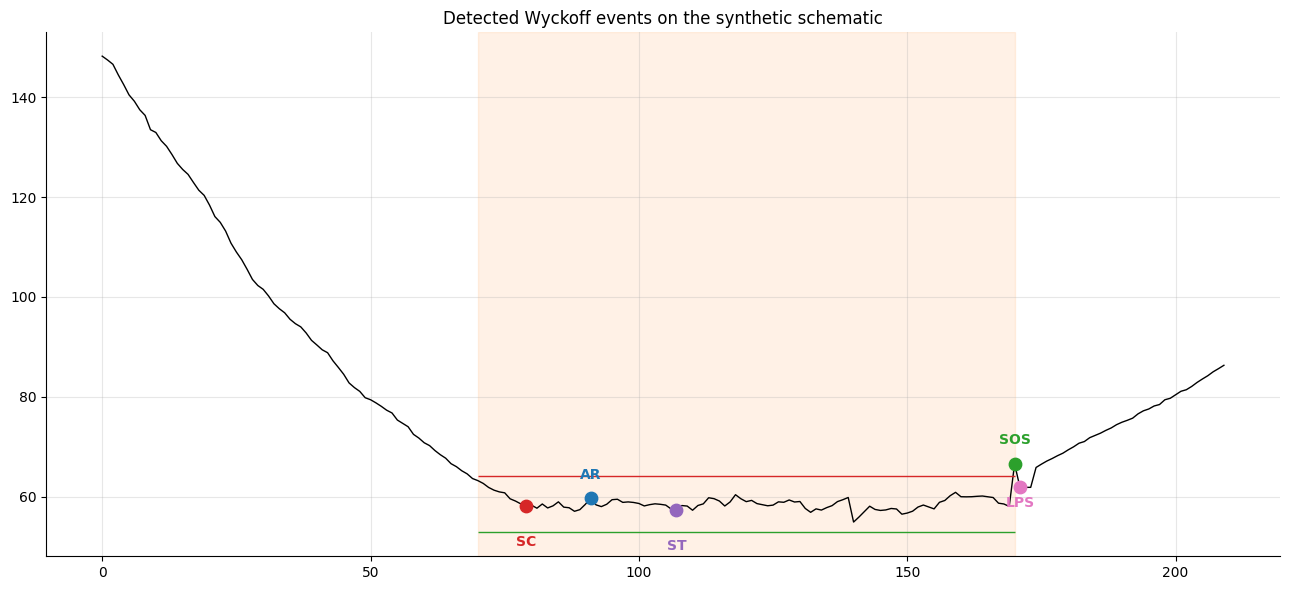

In [12]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(bars.close(), color='black', lw=1.0)
ax.axvspan(rng_first.start_idx, rng_first.end_idx, alpha=0.10, color='C1')
ax.hlines(rng_first.support, rng_first.start_idx, rng_first.end_idx, color='C2', lw=1.0)
ax.hlines(rng_first.resistance, rng_first.start_idx, rng_first.end_idx, color='C3', lw=1.0)

def annot(idx: int, label: str, color: str, dy: float = 5.0) -> None:
    px = float(bars.close()[idx])
    ax.scatter([idx], [px], color=color, s=80, zorder=5)
    ax.annotate(label, (idx, px), xytext=(idx, px + dy),
                fontsize=10, ha='center', color=color, fontweight='bold')

annot(sc.idx, 'SC', 'C3', dy=-8)
if ar is not None:
    annot(ar.idx, 'AR', 'C0', dy=4)
if st is not None:
    annot(st.idx, 'ST', 'C4', dy=-8)
for s in springs:
    annot(s.idx, 'Spring', 'C5', dy=-8)
for s in sos:
    annot(s.idx, 'SOS', 'C2', dy=4)
for s in lps:
    annot(s.idx, 'LPS', 'C6', dy=-4)

ax.set_title('Detected Wyckoff events on the synthetic schematic')
plt.tight_layout()
plt.show()

## 7. Rule-based phase classification (A → E)

Given the events above, `classify_phases` walks them in chronological order per trading range and labels each segment Phase A through E:

* **Phase A** — stopping action (PS / SC / AR / ST).
* **Phase B** — building the cause (oscillation between AR-high and ST-low).
* **Phase C** — test of supply (Spring) or test of demand (UTAD).
* **Phase D** — markup/markdown developing (SOS-LPS or SOW-LPSY).
* **Phase E** — range exit confirmed.

  Acc Phase A: bars [70, 108)
  Acc Phase B: bars [108, 170)
  Acc Phase D: bars [170, 172)
  Acc Phase E: bars [174, 210)


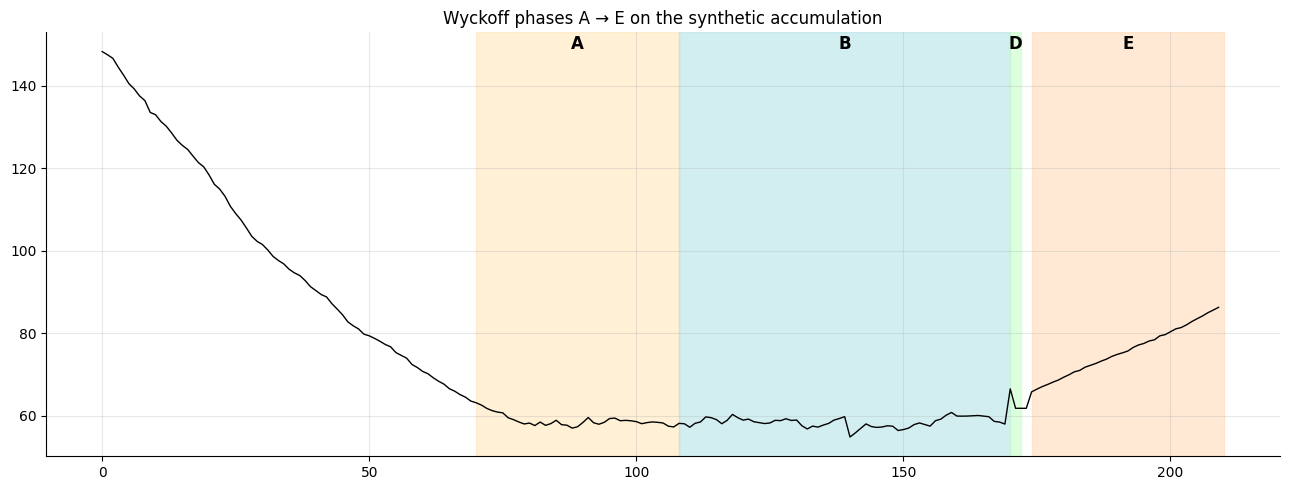

In [13]:
structural_events: list = []
if ar is not None:
    structural_events.append(ar)
if st is not None:
    structural_events.append(st)
structural_events.extend(sos)
structural_events.extend(lps)

phases = classify_phases(bars, [rng_first], climaxes, structural_events, springs)
for p in phases:
    print(f'  {p.schematic} Phase {p.phase}: bars [{p.start_idx}, {p.end_idx})')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(bars.close(), color='black', lw=1.0)
ph_colors = {'A': '#FFE4B5', 'B': '#B0E0E6', 'C': '#F5DEB3', 'D': '#C1FFC1', 'E': '#FFD8B1'}
for p in phases:
    ax.axvspan(p.start_idx, p.end_idx, alpha=0.55, color=ph_colors.get(p.phase, '#DDD'))
    mid = 0.5 * (p.start_idx + p.end_idx)
    ax.text(mid, bars.close().max() * 1.005, p.phase, ha='center', fontweight='bold', fontsize=12)
ax.set_title('Wyckoff phases A → E on the synthetic accumulation')
plt.tight_layout()
plt.show()

## 8. HMM macro-phase classifier

`WyckoffHMMClassifier` fits a 4-state Gaussian HMM (re-using `qufin.markov.ghmm`) on a small feature vector summarising each bar's return, log-volume, and range anomaly. Latent states are relabelled to the canonical macro phases using their mean return and mean log-volume signatures.

This is a *macro* classifier: the rule-based A–E classifier above resolves within-range structure; the HMM gives a probabilistic regime overlay across the full series.

log-likelihood = 282.6
state -> label : {3: 'Markup', 0: 'Markdown', 2: 'Accumulation', 1: 'Distribution'}


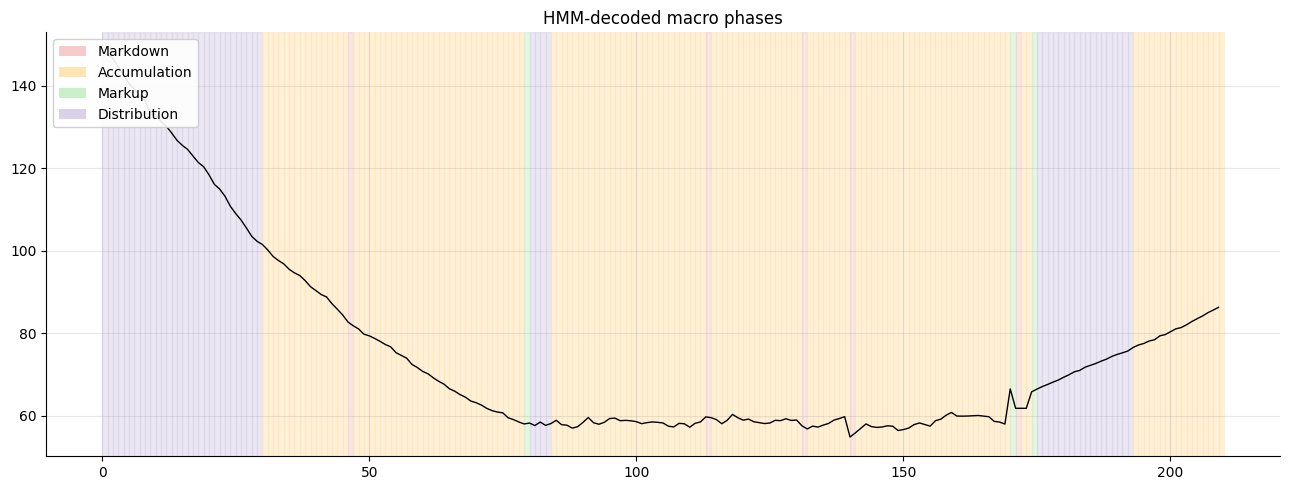

In [14]:
clf = WyckoffHMMClassifier(feature_window=30, n_init=3, max_iter=120, seed=42)
hmm = clf.fit_predict(bars)
print(f'log-likelihood = {hmm.log_likelihood:.1f}')
print(f'state -> label : {hmm.state_to_label}')

label_to_color = {
    'Markdown': '#F4CCCC',
    'Accumulation': '#FFE5B4',
    'Markup': '#C9F0C9',
    'Distribution': '#D9D2E9',
}
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(bars.close(), color='black', lw=1.0)
for i, lbl in enumerate(hmm.labels):
    ax.axvspan(i, i + 1, alpha=0.5, color=label_to_color[lbl])
handles = [plt.Rectangle((0, 0), 1, 1, fc=c) for c in label_to_color.values()]
ax.legend(handles, list(label_to_color), loc='upper left', framealpha=0.9)
ax.set_title('HMM-decoded macro phases')
plt.tight_layout()
plt.show()

## 9. Point-and-Figure & cause-and-effect targets

P&F charts strip out time and noise, keeping only directional moves of at least one box. Each column is either an X (up) or O (down), and a counter-column requires a `reversal`-box move.

Two counts produce price targets from the *Law of Cause and Effect*:

* **Vertical count** — column length × box × reversal, projected from the column's origin.
* **Horizontal count** — width of the base preceding a breakout × box × reversal, projected from the breakout level.

In [15]:
chart = pnf_from_bars(bars, reversal=3)
print(f'box size = {chart.box_size:.3f}   reversal = {chart.reversal}   columns = {chart.n_columns}')

# Show each column's tape.
for k, col in enumerate(chart.columns):
    glyph = 'X' * col.n_boxes if col.direction == 'X' else 'O' * col.n_boxes
    print(f'  col {k:2d}  {col.direction}  bars from {col.start_idx:4d}  [{col.boxes_low:7.2f}, {col.boxes_high:7.2f}]  {glyph}')

box size = 0.899   reversal = 3   columns = 6
  col  0  O  bars from    0  [  57.45,  148.24]  OOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO
  col  1  X  bars from  118  [  58.35,   60.15]  XXX
  col  2  O  bars from  132  [  55.65,   59.25]  OOOOO
  col  3  X  bars from  156  [  56.55,   66.44]  XXXXXXXXXXXX
  col  4  O  bars from  171  [  61.95,   65.54]  OOOOO
  col  5  X  bars from  174  [  62.84,   86.21]  XXXXXXXXXXXXXXXXXXXXXXXXXXX


Vertical count   target = 135.65  (up, count=27)
Horizontal count target = 68.24  (up, base width=2)


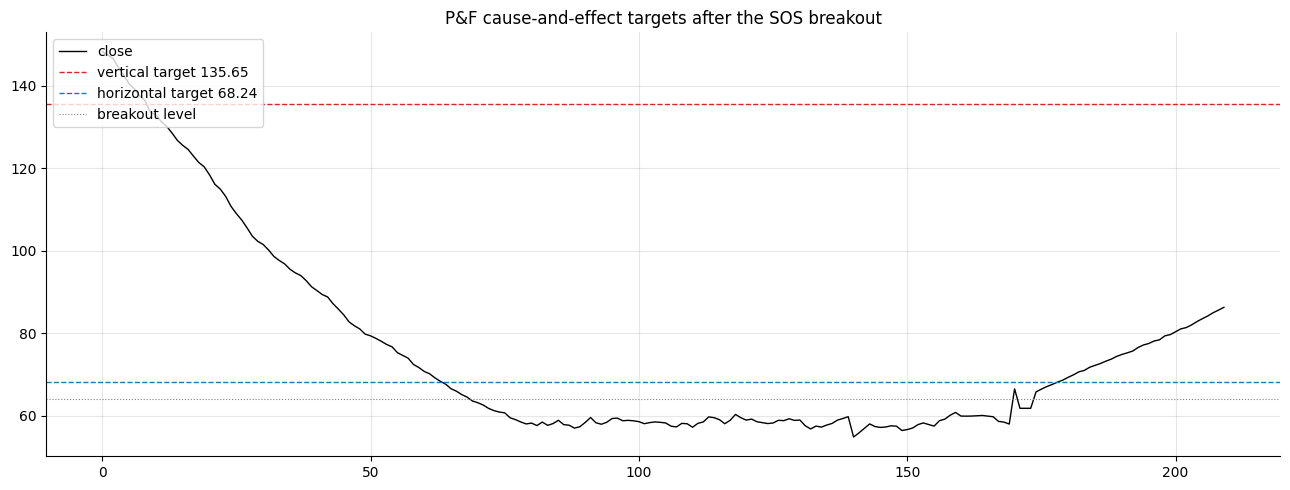

In [16]:
# Vertical count from the breakout column.
breakout_col = chart.n_columns - 1
vt = vertical_count(chart, column_idx=breakout_col)
ht = horizontal_count(chart, column_idx=breakout_col)
print(f'Vertical count   target = {vt.projected_price:.2f}  ({vt.direction}, count={vt.count_boxes})')
print(f'Horizontal count target = {ht.projected_price:.2f}  ({ht.direction}, base width={ht.count_boxes})')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(bars.close(), color='black', lw=1.0, label='close')
ax.axhline(vt.projected_price, color='C3', ls='--', lw=1.0, label=f'vertical target {vt.projected_price:.2f}')
ax.axhline(ht.projected_price, color='C0', ls='--', lw=1.0, label=f'horizontal target {ht.projected_price:.2f}')
ax.axhline(rng_first.resistance, color='gray', ls=':', lw=0.8, label='breakout level')
ax.legend(loc='upper left')
ax.set_title('P&F cause-and-effect targets after the SOS breakout')
plt.tight_layout()
plt.show()

## 10. Wyckoff-style relative strength

A stock is *Wyckoff-strong* if its price holds up or rises against its benchmark during the benchmark's weakness. `relative_strength` is the (optionally rebased) `asset / benchmark` ratio; `rs_rank` returns a cross-sectional rolling rank in `[0, 1]`.

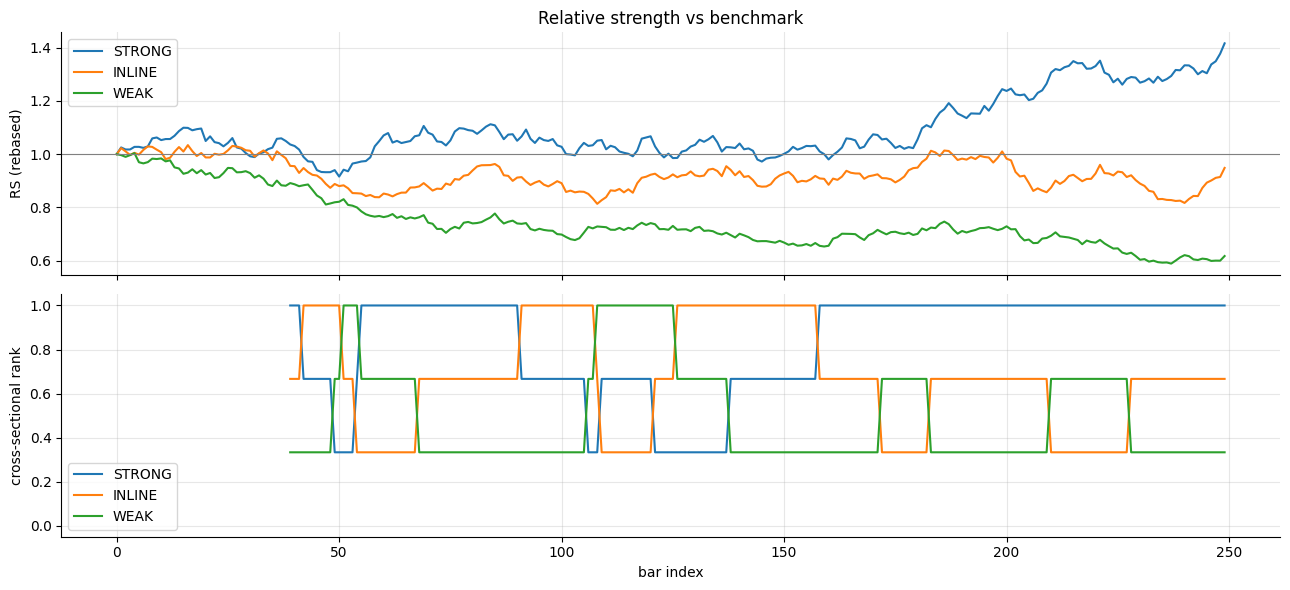

In [17]:
n = 250
rb = np.random.default_rng(99)
benchmark = 100.0 * np.exp(np.cumsum(rb.normal(0.0002, 0.01, n)))

# Build a small universe: one outperformer, one in-line, one underperformer.
universe = {
    'STRONG':  100.0 * np.exp(np.cumsum(rb.normal(0.0015, 0.012, n))),
    'INLINE':  100.0 * np.exp(np.cumsum(rb.normal(0.0002, 0.012, n))),
    'WEAK':    100.0 * np.exp(np.cumsum(rb.normal(-0.001, 0.012, n))),
}
rs = {sym: relative_strength(p, benchmark) for sym, p in universe.items()}
ranks = rs_rank(universe, benchmark, window=40)

fig, (ax_rs, ax_rk) = plt.subplots(2, 1, sharex=True, figsize=(13, 6))
for sym, series in rs.items():
    ax_rs.plot(series, label=sym)
ax_rs.axhline(1.0, color='gray', lw=0.8)
ax_rs.set_ylabel('RS (rebased)')
ax_rs.legend(loc='upper left')
ax_rs.set_title('Relative strength vs benchmark')

for sym, series in ranks.items():
    ax_rk.plot(series, label=sym)
ax_rk.set_ylabel('cross-sectional rank')
ax_rk.set_xlabel('bar index')
ax_rk.set_ylim(-0.05, 1.05)
ax_rk.legend(loc='lower left')
plt.tight_layout()
plt.show()

## What to do next

* Swap the synthetic frame for real bars — anything that loads into a polars DataFrame with the `BAR_SCHEMA` columns works directly:

    ```python
    import yfinance as yf
    raw = yf.download('SPY', start='2020-01-01', end='2024-12-31', interval='1d', auto_adjust=False)
    # Reshape into BAR_SCHEMA columns and pass to OHLCV.from_records.
    ```

* Tune the detector thresholds (`z_volume`, `z_range`, `max_penetration_atr`, `recovery_bars`, …) for your asset and timeframe; the defaults are tuned for daily liquid US equities.
* Combine the HMM macro overlay with the rule-based phase classifier for a two-tier view: the HMM picks the regime, the rule classifier dissects each accumulation/distribution range.
* Use `effort_vs_result` as a continuous feature in a model rather than a binary flag — `divergence = z_effort - z_result` is informative on its own.